<a href="https://colab.research.google.com/github/drisana3508/retail-demand-forecasting-intervals/blob/main/demand_forecasting_M5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile

zip_path = "/content/train.csv.zip"

with zipfile.ZipFile(zip_path, "r") as archive:
    print(archive.namelist())  # Shows the file(s) inside
    archive.extractall("/content")

['train.csv']


In [3]:
import pandas as pd

df = pd.read_csv("/content/train.csv", parse_dates=["date"])

print("Rows and columns:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
display(df.head())

Rows and columns: (913000, 4)
Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate store-item-date rows:")
print(df.duplicated(["date", "store", "item"]).sum())

print("\nStores:", df["store"].nunique())
print("Items:", df["item"].nunique())
print("Sales range:", df["sales"].min(), "to", df["sales"].max())

Missing values:
date     0
store    0
item     0
sales    0
dtype: int64

Duplicate store-item-date rows:
0

Stores: 10
Items: 50
Sales range: 0 to 231


In [5]:
# Keep each store-item time series in date order
df = df.sort_values(["store", "item", "date"]).copy()

# Previous sales for the same store-item pair
grouped_sales = df.groupby(["store", "item"])["sales"]

for lag in [1, 7, 14, 28]:
    df[f"lag_{lag}"] = grouped_sales.shift(lag)

# Recent average and variability.
# Shift by one day first so today's sales aren't used to predict today's sales.
for window in [7, 28]:
    df[f"rolling_mean_{window}"] = grouped_sales.transform(
        lambda s: s.shift(1).rolling(window, min_periods=window).mean()
    )
    df[f"rolling_std_{window}"] = grouped_sales.transform(
        lambda s: s.shift(1).rolling(window, min_periods=window).std()
    )

# Calendar features
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_month"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

display(df.head(35))

,date,store,item,sales,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_28,rolling_std_28,day_of_week,day_of_month,month,week_of_year,is_weekend
0,2013-01-01,1,1,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,0
1,2013-01-02,1,1,11,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,1,0
2,2013-01-03,1,1,14,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,1,1,0
3,2013-01-04,1,1,13,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,1,1,0
4,2013-01-05,1,1,10,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,5,1,1,1
5,2013-01-06,1,1,12,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,6,1,1,1
6,2013-01-07,1,1,10,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,7,1,2,0
7,2013-01-08,1,1,9,10.0,13.0,NaN,NaN,11.857143,1.573592,NaN,NaN,1,8,1,2,0
8,2013-01-09,1,1,12,9.0,11.0,NaN,NaN,11.285714,1.799471,NaN,NaN,2,9,1,2,0
9,2013-01-10,1,1,9,12.0,14.0,NaN,NaN,11.428571,1.812654,NaN,NaN,3,10,1,2,0


In [6]:
# Columns the model is allowed to use
feature_cols = [
    "store", "item",
    "lag_1", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7",
    "rolling_mean_28", "rolling_std_28",
    "day_of_week", "day_of_month", "month",
    "week_of_year", "is_weekend",
]

# Use category types for store and item identifiers
for col in ["store", "item"]:
    df[col] = df[col].astype("category")

# Remove early rows that don't have enough history for all lag features
model_data = df.dropna(subset=feature_cols).copy()

# Keep the latest 28 days for the final test.
# The 28 days immediately before that are reserved for calibration.
dates = sorted(model_data["date"].unique())
cal_start = dates[-56]
test_start = dates[-28]

train = model_data[model_data["date"] < cal_start].copy()
cal = model_data[
    (model_data["date"] >= cal_start) &
    (model_data["date"] < test_start)
].copy()
test = model_data[model_data["date"] >= test_start].copy()

print("Training:", train["date"].min(), "to", train["date"].max(), "| rows:", len(train))
print("Calibration:", cal["date"].min(), "to", cal["date"].max(), "| rows:", len(cal))
print("Test:", test["date"].min(), "to", test["date"].max(), "| rows:", len(test))

Training: 2013-01-29 00:00:00 to 2017-11-05 00:00:00 | rows: 871000
Calibration: 2017-11-06 00:00:00 to 2017-12-03 00:00:00 | rows: 14000
Test: 2017-12-04 00:00:00 to 2017-12-31 00:00:00 | rows: 14000


In [7]:
%pip install -q lightgbm

In [8]:
from lightgbm import LGBMRegressor

quantiles = [0.1, 0.5, 0.9]
models = {}

X_train = train[feature_cols]
y_train = train["sales"]

for q in quantiles:
    print(f"Training q{int(q * 100)} model...")

    model = LGBMRegressor(
        objective="quantile",
        alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    model.fit(
        X_train,
        y_train,
        categorical_feature=["store", "item"],
    )

    models[q] = model

print("All three models are trained.")

Training q10 model...
Training q50 model...
Training q90 model...
All three models are trained.


In [10]:
import numpy as np
import pandas as pd

def make_predictions(data):
    predictions = pd.DataFrame(index=data.index)

    for q in [0.1, 0.5, 0.9]:
        predictions[f"q{int(q * 100)}"] = models[q].predict(data[feature_cols])

    predictions["actual"] = data["sales"].to_numpy()
    predictions["date"] = data["date"].to_numpy()
    predictions["store"] = data["store"].astype(str).to_numpy()
    predictions["item"] = data["item"].astype(str).to_numpy()

    # Quantile models are trained separately, so their outputs can occasionally cross.
    # Sort each row so q10 <= q50 <= q90.
    ordered = np.sort(predictions[["q10", "q50", "q90"]].to_numpy(), axis=1)
    predictions[["q10", "q50", "q90"]] = ordered

    return predictions

cal_pred = make_predictions(cal)
test_pred = make_predictions(test)

display(test_pred.head())

,q10,q50,q90,actual,date,store,item
1798,7.462742,12.616891,18.518987,7,2017-12-04,1,1
1799,9.105519,14.541169,20.610150,20,2017-12-05,1,1
1800,9.143317,14.400707,20.786333,17,2017-12-06,1,1
1801,10.433551,15.715993,20.806576,18,2017-12-07,1,1
1802,12.068766,17.448424,22.986650,17,2017-12-08,1,1


In [11]:
def interval_report(pred, lower_col="q10", upper_col="q90"):
    actual = pred["actual"].to_numpy()
    lower = pred[lower_col].to_numpy()
    upper = pred[upper_col].to_numpy()

    return {
        "coverage": np.mean((actual >= lower) & (actual <= upper)),
        "mean_interval_width": np.mean(upper - lower),
        "below_lower_rate": np.mean(actual < lower),
        "above_upper_rate": np.mean(actual > upper),
    }

print("Calibration results:")
print(interval_report(cal_pred))

print("\nTest results before calibration:")
print(interval_report(test_pred))

Calibration results:
{'coverage': np.float64(0.7893571428571429), 'mean_interval_width': np.float64(19.61414231411677), 'below_lower_rate': np.float64(0.10057142857142858), 'above_upper_rate': np.float64(0.11007142857142857)}

Test results before calibration:
{'coverage': np.float64(0.7849285714285714), 'mean_interval_width': np.float64(16.786120583318734), 'below_lower_rate': np.float64(0.0905), 'above_upper_rate': np.float64(0.12457142857142857)}


In [12]:
alpha = 0.20  # Target 80% coverage

# Positive scores measure how far actual sales fell outside the interval.
cal_scores = np.maximum.reduce([
    cal_pred["q10"].to_numpy() - cal_pred["actual"].to_numpy(),
    cal_pred["actual"].to_numpy() - cal_pred["q90"].to_numpy(),
    np.zeros(len(cal_pred)),
])

# Finite-sample rank for the calibration correction
n = len(cal_scores)
rank = min(n, int(np.ceil((n + 1) * (1 - alpha))))
correction = np.sort(cal_scores)[rank - 1]

print("Interval correction:", correction)

# Widen the final test intervals using only the calibration data
test_pred["lo80"] = test_pred["q10"] - correction
test_pred["hi80"] = test_pred["q90"] + correction

print("\nTest results after calibration:")
print(interval_report(test_pred, "lo80", "hi80"))

Interval correction: 0.23414476392593286

Test results after calibration:
{'coverage': np.float64(0.7983571428571429), 'mean_interval_width': np.float64(17.254410111170603), 'below_lower_rate': np.float64(0.08385714285714285), 'above_upper_rate': np.float64(0.11778571428571429)}


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = test_pred["actual"]
median_forecast = test_pred["q50"]

mae = mean_absolute_error(actual, median_forecast)
rmse = mean_squared_error(actual, median_forecast) ** 0.5

print(f"q50 MAE:  {mae:.3f}")
print(f"q50 RMSE: {rmse:.3f}")

q50 MAE:  5.439
q50 RMSE: 7.081


In [14]:
underage_cost = 4.0  # cost per unit short
overage_cost = 1.0   # cost per leftover unit

actual = test_pred["actual"].to_numpy()

# Example policies: order to the median or to the upper quantile
orders = {
    "q50 policy": np.maximum(test_pred["q50"].to_numpy(), 0),
    "q90 policy": np.maximum(test_pred["q90"].to_numpy(), 0),
}

for policy_name, order_quantity in orders.items():
    shortage = np.maximum(actual - order_quantity, 0)
    leftover = np.maximum(order_quantity - actual, 0)
    cost = underage_cost * shortage + overage_cost * leftover

    print(f"\n{policy_name}")
    print(f"Mean cost per item-day: {cost.mean():.3f}")
    print(f"Mean shortage units:    {shortage.mean():.3f}")
    print(f"Mean leftover units:    {leftover.mean():.3f}")

print("\nCost-optimal quantile for these assumptions:",
      underage_cost / (underage_cost + overage_cost))


q50 policy
Mean cost per item-day: 14.679
Mean shortage units:    3.080
Mean leftover units:    2.359

q90 policy
Mean cost per item-day: 10.138
Mean shortage units:    0.455
Mean leftover units:    8.317

Cost-optimal quantile for these assumptions: 0.8


In [15]:
# Train the quantile that matches the 4:1 shortage/leftover cost ratio
model_q80 = LGBMRegressor(
    objective="quantile",
    alpha=0.8,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

model_q80.fit(
    train[feature_cols],
    train["sales"],
    categorical_feature=["store", "item"],
)

q80_forecast = model_q80.predict(test[feature_cols])

# Compare policies using the same test actuals and cost assumptions
actual = test["sales"].to_numpy()
policies = {
    "q50 policy": test_pred["q50"].to_numpy(),
    "q80 policy": q80_forecast,
    "q90 policy": test_pred["q90"].to_numpy(),
}

for name, order in policies.items():
    order = np.maximum(order, 0)
    shortage = np.maximum(actual - order, 0)
    leftover = np.maximum(order - actual, 0)
    cost = underage_cost * shortage + overage_cost * leftover

    print(
        f"{name}: mean cost={cost.mean():.3f}, "
        f"shortage={shortage.mean():.3f}, "
        f"leftover={leftover.mean():.3f}"
    )

q50 policy: mean cost=14.679, shortage=3.080, leftover=2.359
q80 policy: mean cost=9.806, shortage=0.982, leftover=5.878
q90 policy: mean cost=10.138, shortage=0.455, leftover=8.317


In [17]:
import matplotlib.pyplot as plt

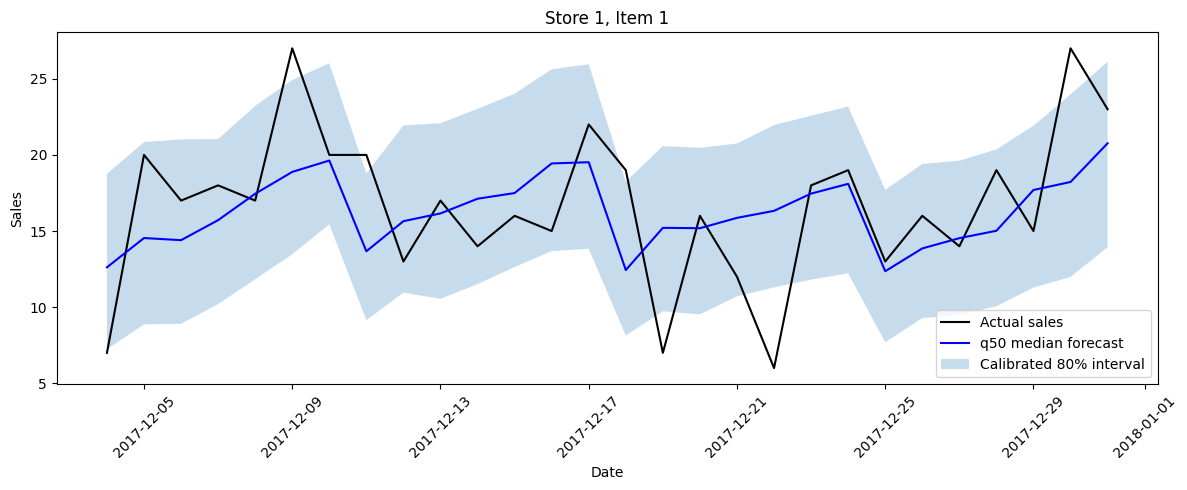

In [18]:
# Choose one store-item series from the test predictions
chosen_store = test_pred["store"].iloc[0]
chosen_item = test_pred["item"].iloc[0]

series = test_pred[
    (test_pred["store"] == chosen_store) &
    (test_pred["item"] == chosen_item)
].sort_values("date")

plt.figure(figsize=(12, 5))
plt.plot(series["date"], series["actual"], label="Actual sales", color="black")
plt.plot(series["date"], series["q50"], label="q50 median forecast", color="blue")
plt.fill_between(
    series["date"],
    series["lo80"],
    series["hi80"],
    alpha=0.25,
    label="Calibrated 80% interval",
)
plt.title(f"Store {chosen_store}, Item {chosen_item}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Add calendar and demand information to the test predictions
diagnostics = test_pred.copy()
diagnostics["day_of_week"] = test.loc[diagnostics.index, "day_of_week"].to_numpy()

diagnostics["covered"] = (
    (diagnostics["actual"] >= diagnostics["lo80"]) &
    (diagnostics["actual"] <= diagnostics["hi80"])
)

# Compare coverage by weekday: 0 = Monday, 6 = Sunday
print("Coverage by weekday (target is about 0.80):")
print(diagnostics.groupby("day_of_week")["covered"].mean().round(3))

# Check whether high-demand days are harder to cover
spike_threshold = diagnostics["actual"].quantile(0.90)
diagnostics["high_demand_day"] = diagnostics["actual"] >= spike_threshold

print("\nCoverage on other days:")
print(diagnostics.loc[~diagnostics["high_demand_day"], "covered"].mean().round(3))

print("\nCoverage on the highest-demand 10% of days:")
print(diagnostics.loc[diagnostics["high_demand_day"], "covered"].mean().round(3))

Coverage by weekday (target is about 0.80):
day_of_week
0    0.818
1    0.814
2    0.794
3    0.769
4    0.803
5    0.804
6    0.786
Name: covered, dtype: float64

Coverage on other days:
0.806

Coverage on the highest-demand 10% of days:
0.731


In [20]:
# Group rows by their predicted median demand level
diagnostics["forecast_demand_band"] = pd.qcut(
    diagnostics["q50"],
    q=5,
    labels=["lowest", "low", "middle", "high", "highest"],
    duplicates="drop",
)

summary = diagnostics.groupby("forecast_demand_band", observed=False).agg(
    rows=("covered", "size"),
    coverage=("covered", "mean"),
    mean_interval_width=("hi80", lambda s: np.nan),  # replaced below
)

# Calculate interval width for each demand band
width_by_band = (
    diagnostics.assign(interval_width=diagnostics["hi80"] - diagnostics["lo80"])
    .groupby("forecast_demand_band", observed=False)["interval_width"]
    .mean()
)

summary["mean_interval_width"] = width_by_band
print(summary.round(3))

                      rows  coverage  mean_interval_width
forecast_demand_band                                     
lowest                2800     0.811               11.440
low                   2800     0.794               14.248
middle                2800     0.808               17.129
high                  2800     0.784               19.785
highest               2800     0.795               23.670


## Results

### Data and evaluation
- Dataset: Store Item Demand Forecasting Challenge
- Training period: 2013-01-29 to 2017-11-05
- Calibration period: 2017-11-06 to 2017-12-03
- Test period: 2017-12-04 to 2017-12-31
- Forecast setup: repeated one-day-ahead predictions

### Forecast quality
- q50 MAE: 5.439
- q50 RMSE: 7.081
- Calibrated q10–q90 test coverage: 79.8% (target: 80%)
- Mean calibrated interval width: 17.25 units

### Inventory comparison
Assumed shortage cost = 4 per unit; leftover cost = 1 per unit.
- q50 mean cost: 14.679 per item-day
- q80 mean cost: 9.806 per item-day
- q90 mean cost: 10.138 per item-day
- q80 had the lowest measured cost among these three policies.

### Reliability notes
- Coverage on the highest-demand 10% of actual days: 73.1%.
- Coverage by predicted-demand band ranged from 78.4% to 81.1%.
- The data has no actual promotion or holiday fields, which may limit the model's ability to anticipate demand spikes.
- The inventory costs use illustrative assumptions and should be replaced with business-specific costs.

In [1]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()  # Select the downloaded M5 ZIP file
zip_name = next(iter(uploaded))

with zipfile.ZipFile(zip_name, "r") as archive:
    archive.extractall("/content")

print("Extracted CSV files:")
for name in os.listdir("/content"):
    if name.endswith(".csv"):
        print(name)

Saving train.csv.zip to train.csv.zip
Extracted CSV files:
train.csv


In [2]:
from google.colab import files
from pathlib import Path
import zipfile

# Select the M5 ZIP file from your computer
uploaded = files.upload()
zip_name = next(iter(uploaded))

# Extract into a separate folder so it doesn't mix with the earlier dataset
extract_dir = Path("/content/m5_data")
extract_dir.mkdir(exist_ok=True)

if not zipfile.is_zipfile(zip_name):
    raise ValueError("That file isn't a ZIP. Please select the M5 Download All ZIP.")

with zipfile.ZipFile(zip_name, "r") as archive:
    archive.extractall(extract_dir)

print("Extracted CSV files:")
csv_files = list(extract_dir.rglob("*.csv"))
for path in csv_files:
    print(path)

expected = {
    "sales_train_validation.csv",
    "calendar.csv",
    "sell_prices.csv",
}
found = {path.name for path in csv_files}
print("\nRequired M5 files found:", expected.issubset(found))

Saving m5-forecasting-accuracy.zip to m5-forecasting-accuracy.zip
Extracted CSV files:
/content/m5_data/sample_submission.csv
/content/m5_data/calendar.csv
/content/m5_data/sales_train_evaluation.csv
/content/m5_data/sell_prices.csv
/content/m5_data/sales_train_validation.csv

Required M5 files found: True


In [3]:
import pandas as pd

sales_path = "/content/m5_data/sales_train_validation.csv"
calendar_path = "/content/m5_data/calendar.csv"
prices_path = "/content/m5_data/sell_prices.csv"

# Identify the daily sales columns, d_1 through d_1913
all_columns = pd.read_csv(sales_path, nrows=0).columns.tolist()
day_cols = [col for col in all_columns if col.startswith("d_")]
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

# Read only one store's rows from the large file, in chunks
store_parts = []
for chunk in pd.read_csv(sales_path, chunksize=1000):
    store_rows = chunk[chunk["store_id"] == "CA_1"]
    if not store_rows.empty:
        store_parts.append(store_rows)

store_sales = pd.concat(store_parts, ignore_index=True)

# Select 30 items reproducibly
sample_wide = store_sales.sample(n=30, random_state=42).copy()
item_ids = sample_wide["item_id"].unique()

# Reshape daily sales from wide columns into one row per item and date
sales_long = sample_wide.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name="d",
    value_name="sales",
)

sales_long["day_num"] = sales_long["d"].str.extract(r"(\d+)").astype(int)

# Add calendar and price information
calendar = pd.read_csv(calendar_path, parse_dates=["date"])
prices = pd.read_csv(prices_path)
prices = prices[
    (prices["store_id"] == "CA_1") &
    (prices["item_id"].isin(item_ids))
]

m5 = (
    sales_long
    .merge(calendar, on="d", how="left")
    .merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")
    .sort_values(["id", "day_num"])
    .reset_index(drop=True)
)

print("Sample series:", m5["id"].nunique())
print("Rows:", len(m5))
print("Date range:", m5["date"].min(), "to", m5["date"].max())
print("Missing prices:", m5["sell_price"].isna().sum())
display(m5.head())

Sample series: 30
Rows: 57390
Date range: 2011-01-29 00:00:00 to 2016-04-24 00:00:00
Missing prices: 15526


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,day_num,date,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_052_CA_1_validation,FOODS_1_052,FOODS_1,FOODS,CA_1,CA,d_1,0,1,2011-01-29,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,FOODS_1_052_CA_1_validation,FOODS_1_052,FOODS_1,FOODS,CA_1,CA,d_2,0,2,2011-01-30,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,FOODS_1_052_CA_1_validation,FOODS_1_052,FOODS_1,FOODS,CA_1,CA,d_3,0,3,2011-01-31,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,FOODS_1_052_CA_1_validation,FOODS_1_052,FOODS_1,FOODS,CA_1,CA,d_4,0,4,2011-02-01,...,2,2011,NaN,NaN,NaN,NaN,1,1,0,NaN
4,FOODS_1_052_CA_1_validation,FOODS_1_052,FOODS_1,FOODS,CA_1,CA,d_5,0,5,2011-02-02,...,2,2011,NaN,NaN,NaN,NaN,1,0,1,NaN


In [4]:
import numpy as np

# M5 calendar, event, SNAP, and price features
m5["day_of_week"] = m5["date"].dt.dayofweek
m5["day_of_month"] = m5["date"].dt.day
m5["month_num"] = m5["date"].dt.month

# This sample is from CA_1, so use California's SNAP indicator
m5["snap"] = m5["snap_CA"].astype(int)

# Preserve missing-price information; LightGBM can handle missing numeric values
m5["price_available"] = m5["sell_price"].notna().astype(int)

# Represent dates with no event as the explicit category "none"
event_cols = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]
for col in event_cols:
    m5[col] = m5[col].fillna("none").astype("category")

# Sales-history features, calculated separately for each item-store series
m5 = m5.sort_values(["id", "day_num"]).copy()
sales_by_series = m5.groupby("id", sort=False)["sales"]

for lag in [1, 7, 14, 28]:
    m5[f"lag_{lag}"] = sales_by_series.shift(lag)

for window in [7, 28]:
    m5[f"rolling_mean_{window}"] = sales_by_series.transform(
        lambda s: s.shift(1).rolling(window, min_periods=window).mean()
    )
    m5[f"rolling_std_{window}"] = sales_by_series.transform(
        lambda s: s.shift(1).rolling(window, min_periods=window).std()
    )

# Store and product identifiers are categorical, not continuous numbers
category_cols = ["item_id", "dept_id", "cat_id", "store_id"]
for col in category_cols:
    m5[col] = m5[col].astype("category")

feature_cols_m5 = [
    "item_id", "dept_id", "cat_id", "store_id",
    "day_of_week", "day_of_month", "month_num", "snap",
    "event_name_1", "event_type_1", "event_name_2", "event_type_2",
    "sell_price", "price_available",
    "lag_1", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7",
    "rolling_mean_28", "rolling_std_28",
]

# First 28 days lack enough past sales to calculate all features
m5_model_data = m5.dropna(
    subset=["lag_28", "rolling_mean_28", "rolling_std_28"]
).copy()

# Keep the latest 56 labeled days for calibration and final testing
train_m5 = m5_model_data[m5_model_data["day_num"] <= 1857].copy()
cal_m5 = m5_model_data[
    m5_model_data["day_num"].between(1858, 1885)
].copy()
test_m5 = m5_model_data[
    m5_model_data["day_num"].between(1886, 1913)
].copy()

print("Training rows:", len(train_m5))
print("Calibration rows:", len(cal_m5))
print("Test rows:", len(test_m5))
print("Training day range:", train_m5["day_num"].min(), "to", train_m5["day_num"].max())
print("Calibration day range:", cal_m5["day_num"].min(), "to", cal_m5["day_num"].max())
print("Test day range:", test_m5["day_num"].min(), "to", test_m5["day_num"].max())
print("Event days in test:", (test_m5["event_name_1"] != "none").sum())

Training rows: 54870
Calibration rows: 840
Test rows: 840
Training day range: 29 to 1857
Calibration day range: 1858 to 1885
Test day range: 1886 to 1913
Event days in test: 0


In [5]:
from lightgbm import LGBMRegressor

quantiles_m5 = [0.1, 0.5, 0.8, 0.9]
categorical_cols_m5 = [
    "item_id", "dept_id", "cat_id", "store_id",
    "event_name_1", "event_type_1", "event_name_2", "event_type_2",
]
models_m5 = {}

X_train_m5 = train_m5[feature_cols_m5]
y_train_m5 = train_m5["sales"]

for q in quantiles_m5:
    print(f"Training M5 q{int(q * 100)} model...")

    model = LGBMRegressor(
        objective="quantile",
        alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    model.fit(
        X_train_m5,
        y_train_m5,
        categorical_feature=categorical_cols_m5,
    )
    models_m5[q] = model

print("All four M5 quantile models are trained.")

Training M5 q10 model...
Training M5 q50 model...
Training M5 q80 model...
Training M5 q90 model...
All four M5 quantile models are trained.


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def predict_m5(frame):
    pred = pd.DataFrame(index=frame.index)

    for q in quantiles_m5:
        pred[f"q{int(q * 100)}"] = models_m5[q].predict(
            frame[feature_cols_m5]
        )

    # Keep all four quantile predictions in order within each row
    q_cols = ["q10", "q50", "q80", "q90"]
    pred[q_cols] = np.sort(pred[q_cols].to_numpy(), axis=1)

    pred["actual"] = frame["sales"].to_numpy()
    pred["date"] = frame["date"].to_numpy()
    pred["day_num"] = frame["day_num"].to_numpy()
    pred["id"] = frame["id"].to_numpy()
    return pred

cal_pred_m5 = predict_m5(cal_m5)
test_pred_m5 = predict_m5(test_m5)

# Calibrate the 80% interval using calibration data only
alpha = 0.20
cal_scores_m5 = np.maximum.reduce([
    cal_pred_m5["q10"].to_numpy() - cal_pred_m5["actual"].to_numpy(),
    cal_pred_m5["actual"].to_numpy() - cal_pred_m5["q90"].to_numpy(),
    np.zeros(len(cal_pred_m5)),
])

n = len(cal_scores_m5)
rank = min(n, int(np.ceil((n + 1) * (1 - alpha))))
correction_m5 = np.sort(cal_scores_m5)[rank - 1]

test_pred_m5["lo80"] = np.maximum(
    0, test_pred_m5["q10"] - correction_m5
)
test_pred_m5["hi80"] = np.maximum(
    0, test_pred_m5["q90"] + correction_m5
)

actual_m5 = test_pred_m5["actual"].to_numpy()
q50_m5 = test_pred_m5["q50"].to_numpy()

coverage_m5 = np.mean(
    (actual_m5 >= test_pred_m5["lo80"]) &
    (actual_m5 <= test_pred_m5["hi80"])
)
width_m5 = np.mean(test_pred_m5["hi80"] - test_pred_m5["lo80"])

print("M5 interval correction:", round(correction_m5, 3))
print("q50 MAE:", round(mean_absolute_error(actual_m5, q50_m5), 3))
print("q50 RMSE:", round(mean_squared_error(actual_m5, q50_m5) ** 0.5, 3))
print("Calibrated interval coverage:", round(coverage_m5, 3), "(target: 0.800)")
print("Mean interval width:", round(width_m5, 3))

M5 interval correction: 0.0
q50 MAE: 0.843
q50 RMSE: 1.472
Calibrated interval coverage: 0.895 (target: 0.800)
Mean interval width: 2.596


In [7]:
# Seasonal-naive point forecast: same item-store sales from one week earlier
naive_forecast_m5 = test_m5["lag_7"].to_numpy()
print(
    "Seasonal-naive MAE:",
    round(mean_absolute_error(actual_m5, naive_forecast_m5), 3)
)
print(
    "Seasonal-naive RMSE:",
    round(mean_squared_error(actual_m5, naive_forecast_m5) ** 0.5, 3)
)

# Estimate seasonal-naive residual quantiles from calibration data only
naive_residuals_m5 = (
    cal_m5["sales"].to_numpy() - cal_m5["lag_7"].to_numpy()
)
resid_q10, resid_q80, resid_q90 = np.quantile(
    naive_residuals_m5, [0.10, 0.80, 0.90]
)

# Baseline 80% interval and q80 stock target
naive_lo80_m5 = np.maximum(
    0, naive_forecast_m5 + resid_q10
)
naive_hi80_m5 = np.maximum(
    0, naive_forecast_m5 + resid_q90
)
naive_q80_order_m5 = np.maximum(
    0, naive_forecast_m5 + resid_q80
)

naive_coverage_m5 = np.mean(
    (actual_m5 >= naive_lo80_m5) &
    (actual_m5 <= naive_hi80_m5)
)
naive_width_m5 = np.mean(naive_hi80_m5 - naive_lo80_m5)

# Compare q80 inventory cost with the same example cost assumptions
def inventory_cost_m5(actual, order, underage=4.0, overage=1.0):
    shortage = np.maximum(actual - order, 0)
    leftover = np.maximum(order - actual, 0)
    cost = underage * shortage + overage * leftover
    return cost.mean(), shortage.mean(), leftover.mean()

naive_cost_m5 = inventory_cost_m5(actual_m5, naive_q80_order_m5)
model_cost_m5 = inventory_cost_m5(
    actual_m5, np.maximum(0, test_pred_m5["q80"].to_numpy())
)

print("\nSeasonal-naive residual interval")
print("Coverage:", round(naive_coverage_m5, 3))
print("Mean width:", round(naive_width_m5, 3))

print("\nq80 inventory cost (shortage cost 4, leftover cost 1)")
print("Seasonal naive — cost, shortage, leftover:",
      tuple(round(x, 3) for x in naive_cost_m5))
print("LightGBM — cost, shortage, leftover:",
      tuple(round(x, 3) for x in model_cost_m5))

Seasonal-naive MAE: 1.15
Seasonal-naive RMSE: 2.023

Seasonal-naive residual interval
Coverage: 0.861
Mean width: 2.682

q80 inventory cost (shortage cost 4, leftover cost 1)
Seasonal naive — cost, shortage, leftover: (np.float64(2.506), np.float64(0.299), np.float64(1.311))
LightGBM — cost, shortage, leftover: (np.float64(1.885), np.float64(0.202), np.float64(1.076))


In [8]:
calendar["day_num"] = calendar["d"].str.extract(r"(\d+)").astype(int)

event_days = calendar[
    (calendar["day_num"] <= 1913) &
    (
        calendar["event_name_1"].notna() |
        calendar["event_name_2"].notna()
    )
][[
    "d", "date",
    "event_name_1", "event_type_1",
    "event_name_2", "event_type_2",
]].sort_values("date")

display(event_days.tail(20))

,d,date,event_name_1,event_type_1,event_name_2,event_type_2
1631,d_1632,2015-07-18,Eid al-Fitr,Religious,NaN,NaN
1682,d_1683,2015-09-07,LaborDay,National,NaN,NaN
1699,d_1700,2015-09-24,EidAlAdha,Religious,NaN,NaN
1717,d_1718,2015-10-12,ColumbusDay,National,NaN,NaN
1736,d_1737,2015-10-31,Halloween,Cultural,NaN,NaN
1747,d_1748,2015-11-11,VeteransDay,National,NaN,NaN
1762,d_1763,2015-11-26,Thanksgiving,National,NaN,NaN
1780,d_1781,2015-12-14,Chanukah End,Religious,NaN,NaN
1791,d_1792,2015-12-25,Christmas,National,NaN,NaN
1798,d_1799,2016-01-01,NewYear,National,NaN,NaN


In [9]:
train_event = m5_model_data[m5_model_data["day_num"] <= 1829].copy()

cal_event = m5_model_data[
    m5_model_data["day_num"].between(1830, 1857)
].copy()

test_event = m5_model_data[
    m5_model_data["day_num"].between(1858, 1885)
].copy()

event_days_in_test = (
    test_event[
        (test_event["event_name_1"] != "none") |
        (test_event["event_name_2"] != "none")
    ][["d", "date", "event_name_1", "event_name_2"]]
    .drop_duplicates("d")
    .sort_values("date")
)

print("Training rows:", len(train_event))
print("Calibration rows:", len(cal_event))
print("Event-test rows:", len(test_event))
print("\nEvent dates in the test window:")
display(event_days_in_test)

Training rows: 54030
Calibration rows: 840
Event-test rows: 840

Event dates in the test window:


,d,date,event_name_1,event_name_2
1874,d_1875,2016-03-17,StPatricksDay,none
1881,d_1882,2016-03-24,Purim End,none
1884,d_1885,2016-03-27,Easter,none


In [10]:
models_event = {}

X_train_event = train_event[feature_cols_m5]
y_train_event = train_event["sales"]

for q in [0.1, 0.5, 0.8, 0.9]:
    print(f"Training event-backtest q{int(q * 100)} model...")

    model = LGBMRegressor(
        objective="quantile",
        alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    model.fit(
        X_train_event,
        y_train_event,
        categorical_feature=categorical_cols_m5,
    )
    models_event[q] = model

print("All event-backtest models are trained.")

Training event-backtest q10 model...
Training event-backtest q50 model...
Training event-backtest q80 model...
Training event-backtest q90 model...
All event-backtest models are trained.


In [11]:
def predict_event_period(frame):
    pred = pd.DataFrame(index=frame.index)

    for q in [0.1, 0.5, 0.8, 0.9]:
        pred[f"q{int(q * 100)}"] = models_event[q].predict(
            frame[feature_cols_m5]
        )

    q_cols = ["q10", "q50", "q80", "q90"]
    pred[q_cols] = np.sort(pred[q_cols].to_numpy(), axis=1)

    pred["actual"] = frame["sales"].to_numpy()
    pred["date"] = frame["date"].to_numpy()
    pred["event_name_1"] = frame["event_name_1"].astype(str).to_numpy()
    pred["event_name_2"] = frame["event_name_2"].astype(str).to_numpy()
    return pred

cal_event_pred = predict_event_period(cal_event)
test_event_pred = predict_event_period(test_event)

# Calibrate q10-q90 interval on the event calibration period
cal_event_scores = np.maximum.reduce([
    cal_event_pred["q10"].to_numpy() - cal_event_pred["actual"].to_numpy(),
    cal_event_pred["actual"].to_numpy() - cal_event_pred["q90"].to_numpy(),
    np.zeros(len(cal_event_pred)),
])

n = len(cal_event_scores)
rank = min(n, int(np.ceil((n + 1) * 0.80)))
event_correction = np.sort(cal_event_scores)[rank - 1]

test_event_pred["lo80"] = np.maximum(
    0, test_event_pred["q10"] - event_correction
)
test_event_pred["hi80"] = np.maximum(
    0, test_event_pred["q90"] + event_correction
)

is_event = (
    (test_event_pred["event_name_1"] != "none") |
    (test_event_pred["event_name_2"] != "none")
)
is_non_event = ~is_event

def coverage_for(mask):
    p = test_event_pred.loc[mask]
    return np.mean(
        (p["actual"] >= p["lo80"]) &
        (p["actual"] <= p["hi80"])
    )

print("Calibration correction:", round(event_correction, 3))
print("Overall test coverage:", round(coverage_for(slice(None)), 3))
print("Event-day coverage:", round(coverage_for(is_event), 3),
      "| event rows:", int(is_event.sum()))
print("Non-event coverage:", round(coverage_for(is_non_event), 3),
      "| non-event rows:", int(is_non_event.sum()))

event_actual = test_event_pred.loc[is_event, "actual"]
event_q50 = test_event_pred.loc[is_event, "q50"]
print("Event-day q50 MAE:",
      round(mean_absolute_error(event_actual, event_q50), 3))


Calibration correction: 0.0
Overall test coverage: 0.882
Event-day coverage: 0.911 | event rows: 90
Non-event coverage: 0.879 | non-event rows: 750
Event-day q50 MAE: 0.565


In [12]:
# Seasonal-naive predictions for these same test rows
naive_event_forecast = test_event.loc[
    test_event_pred.index, "lag_7"
].to_numpy()

actual_event_test = test_event_pred["actual"].to_numpy()
model_q50_event = test_event_pred["q50"].to_numpy()

# q80 baseline uplift estimated only from the event calibration period
naive_residual_event = (
    cal_event["sales"].to_numpy() - cal_event["lag_7"].to_numpy()
)
resid_q80_event = np.quantile(naive_residual_event, 0.80)

naive_q80_order_event = np.maximum(
    0, naive_event_forecast + resid_q80_event
)
model_q80_event = np.maximum(
    0, test_event_pred["q80"].to_numpy()
)

# Same 4:1 shortage-to-leftover assumptions as before
def cost_parts(actual, order):
    shortage = np.maximum(actual - order, 0)
    leftover = np.maximum(order - actual, 0)
    cost = 4.0 * shortage + 1.0 * leftover
    return cost.mean(), shortage.mean(), leftover.mean()

for group_name, mask in [
    ("All test rows", np.ones(len(test_event_pred), dtype=bool)),
    ("Event days", is_event.to_numpy()),
    ("Non-event days", is_non_event.to_numpy()),
]:
    actual_group = actual_event_test[mask]

    naive_mae = mean_absolute_error(
        actual_group, naive_event_forecast[mask]
    )
    model_mae = mean_absolute_error(
        actual_group, model_q50_event[mask]
    )

    naive_cost = cost_parts(actual_group, naive_q80_order_event[mask])
    model_cost = cost_parts(actual_group, model_q80_event[mask])

    print(f"\n{group_name}")
    print(f"q50 MAE — seasonal naive: {naive_mae:.3f}")
    print(f"q50 MAE — LightGBM:       {model_mae:.3f}")
    print(f"q80 cost/shortage/leftover — naive:   {tuple(round(x, 3) for x in naive_cost)}")
    print(f"q80 cost/shortage/leftover — LightGBM: {tuple(round(x, 3) for x in model_cost)}")


All test rows
q50 MAE — seasonal naive: 1.062
q50 MAE — LightGBM:       0.770
q80 cost/shortage/leftover — naive:   (np.float64(2.437), np.float64(0.289), np.float64(1.28))
q80 cost/shortage/leftover — LightGBM: (np.float64(1.833), np.float64(0.205), np.float64(1.015))

Event days
q50 MAE — seasonal naive: 0.767
q50 MAE — LightGBM:       0.565
q80 cost/shortage/leftover — naive:   (np.float64(1.756), np.float64(0.122), np.float64(1.267))
q80 cost/shortage/leftover — LightGBM: (np.float64(1.305), np.float64(0.092), np.float64(0.937))

Non-event days
q50 MAE — seasonal naive: 1.097
q50 MAE — LightGBM:       0.795
q80 cost/shortage/leftover — naive:   (np.float64(2.519), np.float64(0.309), np.float64(1.281))
q80 cost/shortage/leftover — LightGBM: (np.float64(1.896), np.float64(0.218), np.float64(1.024))


In [13]:
diagnostics_event = test_event_pred.copy()

# Add item ID so spike levels are compared within each series
diagnostics_event["id"] = test_event.loc[
    diagnostics_event.index, "id"
].to_numpy()

diagnostics_event["covered"] = (
    (diagnostics_event["actual"] >= diagnostics_event["lo80"]) &
    (diagnostics_event["actual"] <= diagnostics_event["hi80"])
)
diagnostics_event["above_upper"] = (
    diagnostics_event["actual"] > diagnostics_event["hi80"]
)
diagnostics_event["interval_width"] = (
    diagnostics_event["hi80"] - diagnostics_event["lo80"]
)

print("Coverage and interval width by event:")
event_summary = (
    diagnostics_event[diagnostics_event["event_name_1"] != "none"]
    .groupby("event_name_1")
    .agg(
        rows=("covered", "size"),
        coverage=("covered", "mean"),
        above_upper_rate=("above_upper", "mean"),
        mean_width=("interval_width", "mean"),
    )
)
display(event_summary.round(3))

# Identify each series' highest-demand test days retrospectively
series_q90 = diagnostics_event.groupby("id")["actual"].transform(
    lambda values: values.quantile(0.90)
)
spike_days = diagnostics_event["actual"] >= series_q90

print("\nPer-series high-demand days:")
print("Rows:", int(spike_days.sum()))
print("Coverage:", round(diagnostics_event.loc[spike_days, "covered"].mean(), 3))
print("Above-upper miss rate:",
      round(diagnostics_event.loc[spike_days, "above_upper"].mean(), 3))

Coverage and interval width by event:


,rows,coverage,above_upper_rate,mean_width
event_name_1,,,,
Easter,30,0.867,0.133,2.314
Purim End,30,0.900,0.100,2.046
StPatricksDay,30,0.967,0.033,1.926



Per-series high-demand days:
Rows: 230
Coverage: 0.635
Above-upper miss rate: 0.365


In [14]:
# Attach known features to the prediction diagnostics
diagnostics_event["lag_7"] = test_event.loc[
    diagnostics_event.index, "lag_7"
].to_numpy()
diagnostics_event["sell_price"] = test_event.loc[
    diagnostics_event.index, "sell_price"
].to_numpy()
diagnostics_event["snap"] = test_event.loc[
    diagnostics_event.index, "snap"
].to_numpy()

diagnostics_event["upper_excess"] = (
    diagnostics_event["actual"] - diagnostics_event["hi80"]
)

# Show the largest upper-interval misses among high-demand days
worst_spikes = (
    diagnostics_event.loc[spike_days]
    .nlargest(10, "upper_excess")[
        [
            "id", "date", "event_name_1", "actual",
            "q50", "q90", "hi80", "lag_7",
            "sell_price", "snap", "upper_excess",
        ]
    ]
)

display(worst_spikes)

,id,date,event_name_1,actual,q50,q90,hi80,lag_7,sell_price,snap,upper_excess
26731,FOODS_3_643_CA_1_validation,2016-03-05,none,10,1.957954,5.716116,5.716116,3.0,1.74,1,4.283884
7599,FOODS_2_257_CA_1_validation,2016-03-03,none,9,1.035675,4.772559,4.772559,0.0,1.00,1,4.227441
49703,HOUSEHOLD_2_349_CA_1_validation,2016-03-21,none,5,0.000000,1.313478,1.313478,0.0,4.97,0,3.686522
28645,FOODS_3_744_CA_1_validation,2016-03-06,none,26,15.933268,22.583565,22.583565,12.0,2.28,1,3.416435
17184,FOODS_3_207_CA_1_validation,2016-03-23,none,4,0.000000,0.734283,0.734283,0.0,1.98,0,3.265717
28660,FOODS_3_744_CA_1_validation,2016-03-21,none,19,10.928693,15.928637,15.928637,14.0,2.28,0,3.071363
38229,HOUSEHOLD_1_331_CA_1_validation,2016-03-25,none,5,0.167355,2.094571,2.094571,0.0,4.88,0,2.905429
47775,HOUSEHOLD_2_341_CA_1_validation,2016-03-06,none,5,1.004505,2.395740,2.395740,1.0,5.32,1,2.604260
5701,FOODS_2_135_CA_1_validation,2016-03-18,none,6,0.367333,3.590252,3.590252,0.0,2.48,0,2.409748
32485,HOBBIES_1_352_CA_1_validation,2016-03-20,none,3,0.116907,0.951365,0.951365,0.0,2.74,0,2.048635


In [15]:
# Signed conformal scores: these can be negative when intervals are too wide
signed_scores = np.maximum(
    cal_event_pred["q10"].to_numpy() - cal_event_pred["actual"].to_numpy(),
    cal_event_pred["actual"].to_numpy() - cal_event_pred["q90"].to_numpy(),
)

n = len(signed_scores)
rank = min(n, int(np.ceil((n + 1) * 0.80)))
signed_correction = np.sort(signed_scores)[rank - 1]

# Apply the correction; if negative, this narrows the interval
test_event_pred["lo80_signed"] = np.maximum(
    0, test_event_pred["q10"] - signed_correction
)
test_event_pred["hi80_signed"] = np.maximum(
    test_event_pred["lo80_signed"],
    test_event_pred["q90"] + signed_correction,
)

covered_signed = (
    (test_event_pred["actual"] >= test_event_pred["lo80_signed"]) &
    (test_event_pred["actual"] <= test_event_pred["hi80_signed"])
)

print("Signed calibration correction:", round(signed_correction, 3))
print("Coverage after signed calibration:", round(covered_signed.mean(), 3))
print("Mean interval width:",
      round((test_event_pred["hi80_signed"] -
             test_event_pred["lo80_signed"]).mean(), 3))

Signed calibration correction: 0.0
Coverage after signed calibration: 0.882
Mean interval width: 2.45


In [16]:
target_stores = ["CA_1", "TX_1", "WI_1"]
store_parts_larger = []

# Read the sales file in chunks, keeping only the three selected stores
for chunk in pd.read_csv(sales_path, chunksize=1000):
    selected = chunk[chunk["store_id"].isin(target_stores)]
    if not selected.empty:
        store_parts_larger.append(selected)

sales_three_stores = pd.concat(store_parts_larger, ignore_index=True)

# Randomly select 100 product series from each store
sample_parts = []
for store_id in target_stores:
    store_rows = sales_three_stores[
        sales_three_stores["store_id"] == store_id
    ]
    sample_parts.append(
        store_rows.sample(n=100, random_state=42)
    )

sample_wide_larger = pd.concat(sample_parts, ignore_index=True)

print("Stores:", sorted(sample_wide_larger["store_id"].unique()))
print("Series:", sample_wide_larger["id"].nunique())
print(sample_wide_larger.groupby("store_id").size())

Stores: ['CA_1', 'TX_1', 'WI_1']
Series: 300
store_id
CA_1    100
TX_1    100
WI_1    100
dtype: int64


In [17]:
# Reshape the 300 selected sales series into daily rows
sales_long_large = sample_wide_larger.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name="d",
    value_name="sales",
)
sales_long_large["day_num"] = (
    sales_long_large["d"].str.extract(r"(\d+)").astype(int)
)

# Avoid a duplicate day_num column when joining the calendar
calendar_for_join = calendar.drop(columns=["day_num"], errors="ignore")

# Keep only prices for the sampled item-store pairs
sample_pairs = sample_wide_larger[["store_id", "item_id"]].drop_duplicates()
prices_full = pd.read_csv(prices_path)
prices_large = prices_full.merge(
    sample_pairs,
    on=["store_id", "item_id"],
    how="inner",
)

# Join date, events, SNAP flags, and weekly prices
m5_large = (
    sales_long_large
    .merge(calendar_for_join, on="d", how="left")
    .merge(prices_large, on=["store_id", "item_id", "wm_yr_wk"], how="left")
)

# Use the SNAP indicator for each row's state
m5_large["snap"] = np.select(
    [
        m5_large["state_id"] == "CA",
        m5_large["state_id"] == "TX",
        m5_large["state_id"] == "WI",
    ],
    [
        m5_large["snap_CA"],
        m5_large["snap_TX"],
        m5_large["snap_WI"],
    ],
    default=0,
).astype(int)

m5_large["price_available"] = m5_large["sell_price"].notna().astype(int)
m5_large["day_of_week"] = m5_large["date"].dt.dayofweek
m5_large["day_of_month"] = m5_large["date"].dt.day
m5_large["month_num"] = m5_large["date"].dt.month

event_cols = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]
for col in event_cols:
    m5_large[col] = m5_large[col].fillna("none").astype("category")

m5_large = m5_large.sort_values(["id", "day_num"]).copy()
sales_by_id_large = m5_large.groupby("id", sort=False)["sales"]

for lag in [1, 7, 14, 28]:
    m5_large[f"lag_{lag}"] = sales_by_id_large.shift(lag)

for window in [7, 28]:
    m5_large[f"rolling_mean_{window}"] = sales_by_id_large.transform(
        lambda s: s.shift(1).rolling(window, min_periods=window).mean()
    )
    m5_large[f"rolling_std_{window}"] = sales_by_id_large.transform(
        lambda s: s.shift(1).rolling(window, min_periods=window).std()
    )

category_cols_large = [
    "item_id", "dept_id", "cat_id", "store_id",
    "event_name_1", "event_type_1", "event_name_2", "event_type_2",
]
for col in ["item_id", "dept_id", "cat_id", "store_id"]:
    m5_large[col] = m5_large[col].astype("category")

feature_cols_large = [
    "item_id", "dept_id", "cat_id", "store_id",
    "day_of_week", "day_of_month", "month_num", "snap",
    "event_name_1", "event_type_1", "event_name_2", "event_type_2",
    "sell_price", "price_available",
    "lag_1", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7",
    "rolling_mean_28", "rolling_std_28",
]

m5_large = m5_large.dropna(
    subset=["lag_28", "rolling_mean_28", "rolling_std_28"]
).copy()

# Two rolling-origin folds: one contains holidays, the other is the latest period
train_event_large = m5_large[m5_large["day_num"] <= 1829].copy()
cal_event_large = m5_large[m5_large["day_num"].between(1830, 1857)].copy()
test_event_large = m5_large[m5_large["day_num"].between(1858, 1885)].copy()

train_recent_large = m5_large[m5_large["day_num"] <= 1857].copy()
cal_recent_large = m5_large[m5_large["day_num"].between(1858, 1885)].copy()
test_recent_large = m5_large[m5_large["day_num"].between(1886, 1913)].copy()

print("Panel rows:", len(m5_large))
print("Series:", m5_large["id"].nunique())
print("Rows per state:")
print(m5_large.groupby("state_id", observed=True)["id"].nunique())
print("\nEvent fold train/calibration/test:",
      len(train_event_large), len(cal_event_large), len(test_event_large))
print("Recent fold train/calibration/test:",
      len(train_recent_large), len(cal_recent_large), len(test_recent_large))

Panel rows: 565500
Series: 300
Rows per state:
state_id
CA    100
TX    100
WI    100
Name: id, dtype: int64

Event fold train/calibration/test: 540300 8400 8400
Recent fold train/calibration/test: 548700 8400 8400


In [18]:
from lightgbm import LGBMRegressor

def fit_m5_quantiles(train_frame):
    fitted = {}

    for q in [0.1, 0.5, 0.8, 0.9]:
        print(f"Training q{int(q * 100)}...")

        model = LGBMRegressor(
            objective="quantile",
            alpha=q,
            n_estimators=350,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=50,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbosity=-1,
        )

        model.fit(
            train_frame[feature_cols_large],
            train_frame["sales"],
            categorical_feature=category_cols_large,
        )
        fitted[q] = model

    return fitted

print("Event fold models:")
models_event_large = fit_m5_quantiles(train_event_large)

print("\nRecent fold models:")
models_recent_large = fit_m5_quantiles(train_recent_large)

print("\nBoth folds are trained.")

Event fold models:
Training q10...
Training q50...
Training q80...
Training q90...

Recent fold models:
Training q10...
Training q50...
Training q80...
Training q90...

Both folds are trained.


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def make_m5_predictions(frame, models):
    pred = pd.DataFrame(index=frame.index)

    for q in [0.1, 0.5, 0.8, 0.9]:
        pred[f"q{int(q * 100)}"] = models[q].predict(
            frame[feature_cols_large]
        )

    q_cols = ["q10", "q50", "q80", "q90"]
    pred[q_cols] = np.sort(pred[q_cols].to_numpy(), axis=1)

    for col in ["sales", "lag_7", "id", "store_id",
                "event_name_1", "event_name_2"]:
        pred[col] = frame[col].to_numpy()

    return pred


def evaluate_m5_fold(name, cal_frame, test_frame, models):
    cal_pred = make_m5_predictions(cal_frame, models)
    test_pred = make_m5_predictions(test_frame, models)

    # Signed conformal correction from this fold's calibration block
    scores = np.maximum(
        cal_pred["q10"].to_numpy() - cal_pred["sales"].to_numpy(),
        cal_pred["sales"].to_numpy() - cal_pred["q90"].to_numpy(),
    )
    n = len(scores)
    rank = min(n, int(np.ceil((n + 1) * 0.80)))
    correction = np.sort(scores)[rank - 1]

    test_pred["lo80"] = np.maximum(
        0, test_pred["q10"] - correction
    )
    test_pred["hi80"] = np.maximum(
        test_pred["lo80"], test_pred["q90"] + correction
    )
    test_pred["covered"] = (
        (test_pred["sales"] >= test_pred["lo80"]) &
        (test_pred["sales"] <= test_pred["hi80"])
    )

    actual = test_pred["sales"].to_numpy()
    model_q50 = test_pred["q50"].to_numpy()
    naive = test_pred["lag_7"].to_numpy()

    # Seasonal-naive residual intervals and q80 order target
    residuals = cal_frame["sales"].to_numpy() - cal_frame["lag_7"].to_numpy()
    r10, r80, r90 = np.quantile(residuals, [0.10, 0.80, 0.90])

    naive_lo = np.maximum(0, naive + r10)
    naive_hi = np.maximum(0, naive + r90)
    naive_interval_coverage = np.mean((actual >= naive_lo) & (actual <= naive_hi))
    naive_interval_width = np.mean(naive_hi - naive_lo)

    naive_q80_order = np.maximum(0, naive + r80)
    model_q80_order = np.maximum(0, test_pred["q80"].to_numpy())

    def avg_cost(order):
        shortage = np.maximum(actual - order, 0)
        leftover = np.maximum(order - actual, 0)
        return np.mean(4.0 * shortage + leftover)

    is_event = (
        (test_pred["event_name_1"].astype(str) != "none") |
        (test_pred["event_name_2"].astype(str) != "none")
    ).to_numpy()

    # Per-series 90th percentile; ties can make this group larger than 10%.
    thresholds = test_pred.groupby("id")["sales"].transform(
        lambda values: values.quantile(0.90)
    )
    high_demand = (test_pred["sales"] >= thresholds).to_numpy()

    print(f"\n{name}")
    print("q50 MAE — seasonal naive / LightGBM:",
          round(mean_absolute_error(actual, naive), 3), "/",
          round(mean_absolute_error(actual, model_q50), 3))
    print("q50 RMSE — seasonal naive / LightGBM:",
          round(mean_squared_error(actual, naive) ** 0.5, 3), "/",
          round(mean_squared_error(actual, model_q50) ** 0.5, 3))
    print("Interval correction:", round(correction, 3))
    print("LightGBM interval coverage / width:",
          round(test_pred["covered"].mean(), 3), "/",
          round((test_pred["hi80"] - test_pred["lo80"]).mean(), 3))
    print("Naive residual interval coverage / width:",
          round(naive_interval_coverage, 3), "/",
          round(naive_interval_width, 3))
    print("Event-day coverage:",
          round(test_pred.loc[is_event, "covered"].mean(), 3)
          if is_event.sum() else "no event days")
    print("High-demand subset coverage / rows:",
          round(test_pred.loc[high_demand, "covered"].mean(), 3), "/",
          int(high_demand.sum()))
    print("q80 inventory cost — seasonal naive / LightGBM:",
          round(avg_cost(naive_q80_order), 3), "/",
          round(avg_cost(model_q80_order), 3))

    return test_pred


event_results = evaluate_m5_fold(
    "Event fold (d_1858–d_1885)",
    cal_event_large,
    test_event_large,
    models_event_large,
)

recent_results = evaluate_m5_fold(
    "Recent fold (d_1886–d_1913)",
    cal_recent_large,
    test_recent_large,
    models_recent_large,
)


Event fold (d_1858–d_1885)
q50 MAE — seasonal naive / LightGBM: 1.074 / 0.794
q50 RMSE — seasonal naive / LightGBM: 2.243 / 1.749
Interval correction: 0.0
LightGBM interval coverage / width: 0.908 / 2.564
Naive residual interval coverage / width: 0.878 / 2.65
Event-day coverage: 0.916
High-demand subset coverage / rows: 0.739 / 2562
q80 inventory cost — seasonal naive / LightGBM: 2.43 / 1.856

Recent fold (d_1886–d_1913)
q50 MAE — seasonal naive / LightGBM: 1.094 / 0.808
q50 RMSE — seasonal naive / LightGBM: 2.136 / 1.678
Interval correction: 0.0
LightGBM interval coverage / width: 0.908 / 2.626
Naive residual interval coverage / width: 0.876 / 2.66
Event-day coverage: no event days
High-demand subset coverage / rows: 0.711 / 2349
q80 inventory cost — seasonal naive / LightGBM: 2.457 / 1.861


In [21]:
evaluation_path = "/content/m5_data/sales_train_evaluation.csv"
evaluation_days = [f"d_{i}" for i in range(1914, 1942)]

# Match exact store-item pairs, ignoring the differing ID suffix
sample_pairs_index = pd.MultiIndex.from_frame(
    sample_wide_larger[["store_id", "item_id"]].drop_duplicates()
)

eval_parts = []

for chunk in pd.read_csv(
    evaluation_path,
    usecols=id_cols + evaluation_days,
    chunksize=2000,
):
    row_pairs = pd.MultiIndex.from_frame(chunk[["store_id", "item_id"]])
    selected = chunk[row_pairs.isin(sample_pairs_index)]
    if not selected.empty:
        eval_parts.append(selected)

if not eval_parts:
    raise ValueError("No sampled store-item pairs matched the evaluation file.")

evaluation_wide = pd.concat(eval_parts, ignore_index=True)

# Make IDs consistent with sales_train_validation.csv for joining
evaluation_wide["id"] = evaluation_wide["id"].str.replace(
    r"_evaluation$", "_validation", regex=True
)

print("Matched series:", evaluation_wide["id"].nunique())
print("Expected series:", len(sample_pairs_index))
print("Available holdout days:", len(evaluation_days))
display(evaluation_wide.head())

Matched series: 300
Expected series: 300
Available holdout days: 28


,id,item_id,dept_id,cat_id,store_id,state_id,d_1914,d_1915,d_1916,d_1917,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_045_CA_1_validation,HOBBIES_1_045,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,2,0,1,0
1,HOBBIES_1_052_CA_1_validation,HOBBIES_1_052,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,HOBBIES_1_053_CA_1_validation,HOBBIES_1_053,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
3,HOBBIES_1_065_CA_1_validation,HOBBIES_1_065,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,HOBBIES_1_107_CA_1_validation,HOBBIES_1_107,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [22]:
# Reshape the later evaluation labels into daily rows
evaluation_long = evaluation_wide.melt(
    id_vars=id_cols,
    value_vars=evaluation_days,
    var_name="d",
    value_name="sales",
)
evaluation_long["day_num"] = (
    evaluation_long["d"].str.extract(r"(\d+)").astype(int)
)

# Join later labels to the historical daily panel
history_long = sales_long_large[
    id_cols + ["d", "sales", "day_num"]
].copy()

combined_long = pd.concat(
    [history_long, evaluation_long],
    ignore_index=True,
)

m5_final = (
    combined_long
    .merge(calendar_for_join, on="d", how="left")
    .merge(prices_large, on=["store_id", "item_id", "wm_yr_wk"], how="left")
)

# State-specific SNAP indicator
m5_final["snap"] = np.select(
    [
        m5_final["state_id"] == "CA",
        m5_final["state_id"] == "TX",
        m5_final["state_id"] == "WI",
    ],
    [
        m5_final["snap_CA"],
        m5_final["snap_TX"],
        m5_final["snap_WI"],
    ],
    default=0,
).astype(int)

m5_final["price_available"] = m5_final["sell_price"].notna().astype(int)
m5_final["day_of_week"] = m5_final["date"].dt.dayofweek
m5_final["day_of_month"] = m5_final["date"].dt.day
m5_final["month_num"] = m5_final["date"].dt.month

for col in event_cols:
    m5_final[col] = m5_final[col].fillna("none").astype("category")

m5_final = m5_final.sort_values(["id", "day_num"]).copy()
sales_by_id_final = m5_final.groupby("id", sort=False)["sales"]

for lag in [1, 7, 14, 28]:
    m5_final[f"lag_{lag}"] = sales_by_id_final.shift(lag)

for window in [7, 28]:
    m5_final[f"rolling_mean_{window}"] = sales_by_id_final.transform(
        lambda s: s.shift(1).rolling(window, min_periods=window).mean()
    )
    m5_final[f"rolling_std_{window}"] = sales_by_id_final.transform(
        lambda s: s.shift(1).rolling(window, min_periods=window).std()
    )

for col in ["item_id", "dept_id", "cat_id", "store_id"]:
    m5_final[col] = m5_final[col].astype("category")

m5_final = m5_final.dropna(
    subset=["lag_28", "rolling_mean_28", "rolling_std_28"]
).copy()

train_final = m5_final[m5_final["day_num"] <= 1885].copy()
cal_final = m5_final[m5_final["day_num"].between(1886, 1913)].copy()
test_final = m5_final[m5_final["day_num"].between(1914, 1941)].copy()

print("Series:", m5_final["id"].nunique())
print("Final train/calibration/test rows:",
      len(train_final), len(cal_final), len(test_final))
print("Test dates:", test_final["date"].min(), "to", test_final["date"].max())

test_event_dates = (
    test_final[
        (test_final["event_name_1"] != "none") |
        (test_final["event_name_2"] != "none")
    ][["d", "date", "event_name_1", "event_name_2"]]
    .drop_duplicates("d")
    .sort_values("date")
)
print("Event dates in final test:")
display(test_event_dates)

Series: 300
Final train/calibration/test rows: 557100 8400 8400
Test dates: 2016-04-25 00:00:00 to 2016-05-22 00:00:00
Event dates in final test:


,d,date,event_name_1,event_name_2
575455,d_1919,2016-04-30,Pesach End,none
575755,d_1920,2016-05-01,OrthodoxEaster,none
576955,d_1924,2016-05-05,Cinco De Mayo,none
577855,d_1927,2016-05-08,Mother's day,none


In [23]:
print("Training final M5 models...")
models_final = fit_m5_quantiles(train_final)

print("\nEvaluating the fresh final holdout...")
final_results = evaluate_m5_fold(
    "Fresh final holdout (d_1914–d_1941)",
    cal_final,
    test_final,
    models_final,
)

Training final M5 models...
Training q10...
Training q50...
Training q80...
Training q90...

Evaluating the fresh final holdout...

Fresh final holdout (d_1914–d_1941)
q50 MAE — seasonal naive / LightGBM: 1.153 / 0.836
q50 RMSE — seasonal naive / LightGBM: 2.169 / 1.606
Interval correction: 0.0
LightGBM interval coverage / width: 0.898 / 2.648
Naive residual interval coverage / width: 0.869 / 2.679
Event-day coverage: 0.892
High-demand subset coverage / rows: 0.652 / 2098
q80 inventory cost — seasonal naive / LightGBM: 2.512 / 1.909


## M5 extension: results on a 300-series sample

The M5 experiment extends the Store Item project with calendar events, state-specific SNAP indicators, sell prices, and the same lag and rolling-sales features.

To keep the experiment manageable in Colab, the sample contains 300 item-store series: 100 each from CA_1, TX_1, and WI_1. The forecasts are repeated one day ahead, using only sales available before each forecast date. Results are from three consecutive 28-day test folds.

The 80% prediction interval is formed from q10 and q90 forecasts. Inventory cost assumes a shortage cost of 4 per unit and a leftover cost of 1 per unit.

| Test fold | q50 MAE: naive / LightGBM | q50 RMSE: naive / LightGBM | Interval coverage | Mean interval width | Event-day coverage | High-demand coverage | q80 cost: naive / LightGBM |
|---|---:|---:|---:|---:|---:|---:|---:|
| d_1858–d_1885, event period | 1.074 / 0.794 | 2.243 / 1.749 | 90.8% | 2.564 | 91.6% | 73.9% | 2.430 / 1.856 |
| d_1886–d_1913, recent period | 1.094 / 0.808 | 2.136 / 1.678 | 90.8% | 2.626 | No event days | 71.1% | 2.457 / 1.861 |
| d_1914–d_1941, final holdout | 1.153 / 0.836 | 2.169 / 1.606 | 89.8% | 2.648 | 89.2% | 65.2% | 2.512 / 1.909 |

LightGBM had lower q50 MAE, q50 RMSE, and q80 inventory cost than seasonal naive in all three folds. Its q10–q90 intervals covered about 90% of test rows, above their nominal 80% target, so they were conservative overall. Coverage was lower on the high-demand subset, showing that the intervals still miss many demand spikes. The calibration correction was zero in each fold.

High-demand rows are defined using each series’ 90th-percentile test demand, with ties included; this can make the subset larger than 10% of rows. The event fold includes St. Patrick’s Day, Purim, and Easter. The final holdout includes Pesach End, Orthodox Easter, Cinco de Mayo, and Mother’s Day.

These are sample-based results, not full M5 competition results. The sample includes three stores and 300 series, and the inventory costs are illustrative. The dataset does not provide a direct promotion flag; event, SNAP, and price features are used as available demand signals.